The purpose of this project is to understand how price changes affect demand in the Airbnb market.
Specifically, we aim to estimate price elasticity of demand, which tells us how sensitive booking demand is to changes in price.
# Import Required Libraries

This cell loads all the necessary Python and Spark libraries used throughout the analysis:
PySpark SQL for distributed data processing
PySpark ML for running the regression model that estimates price elasticity
Matplotlib & Pandas for data visualization
These tools together enable scalable ETL, modeling, and plotting of results for the Airbnb dataset.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
import matplotlib.pyplot as plt
import pandas as pd


# Create Spark Session

I initialize a Spark session on the Dataproc cluster.
This session serves as the main entry point for executing distributed operations such as reading large files, cleaning data, and running ML models.

In [2]:
spark = SparkSession.builder.appName("AirbnbElasticityFixed").getOrCreate()


25/12/16 17:38:57 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


# Load Raw Airbnb Calendar and Listing Data
## The listings dataset contains static property attributes, including:
    Listing ID
    Base price
    Location information
This dataset provides the price anchor for each Airbnb listing.
## I loaded daily calendar-level data which includes:
    Listing ID
    Date
    Availability flag
    Calendar price (actual transactional price)

## In this step:
The calendar dataset is loaded (contains daily prices and availability for each listing).
The listing dataset is loaded (contains listing-level information such as room type, ratings, and accommodates).
Both datasets are read from Google Cloud Storage.
These datasets form the foundation for analyzing how price influences daily booking demand.

In [3]:
calendar_path = "gs://bia678-airbnb-data/raw/nyc/calendar/*.csv.gz"
listing_path  = "gs://bia678-airbnb-data/raw/nyc/listing/*.csv"

calendar_raw = spark.read.csv(calendar_path, header=True, inferSchema=False)
listing_raw  = spark.read.csv(listing_path, header=True, inferSchema=True)


# Clean Price Field & Create Booking Indicator

## This cell performs essential ETL:
    Price Cleaning
    Remove $ and , characters
    Convert price to numeric
    Filter invalid or extreme values (below $10 or above $2000)
## Define Demand
    We create a booked column:
    1 = booked
    0 = available
This variable will act as our demand indicator, enabling log–log elasticity modeling.

In [4]:
calendar_df = (
    calendar_raw
    .withColumn("price_str", F.regexp_replace("price", "[$,]", ""))
    .withColumn(
        "price_str",
        F.when(F.col("price_str").rlike("^[0-9.]+$"), F.col("price_str"))
         .otherwise(None)
    )
    .withColumn("price_clean", F.col("price_str").cast("double"))
    .filter("price_clean IS NOT NULL AND price_clean > 10 AND price_clean < 2000")
    .withColumn("booked", (1 - (F.col("available") == "t").cast("int")))
)


## Select Relevant Listing Attributes

We extract important listing attributes:

Room type

Review score rating

Accommodation capacity

These features help us understand potential demand drivers.
The listing ID is also renamed for proper joining with the calendar dataset.

In [5]:
listing_df = (
    listing_raw
    .select(
        "id",
        "room_type",
        "review_scores_rating",
        "accommodates"
    )
    .withColumnRenamed("id", "listing_id")
)


# Join Calendar and Listing Tables
## We merge the cleaned calendar dataset with the listing dataset using listing_id.
    Every row represents one listing on one day
    Contains price, availability, and listing characteristics
    This produces the working dataset used to analyze the relationship between price and demand.

In [6]:
airbnb = calendar_df.join(listing_df, "listing_id", "inner")


# Visualize Price Distribution
# This histogram helps us validate the cleaned price data and understand:
    The range of nightly prices
    How skewed the distribution is (typical for Airbnb markets)
    Whether log-transformation is appropriate
    Understanding the distribution ensures correct model specification.

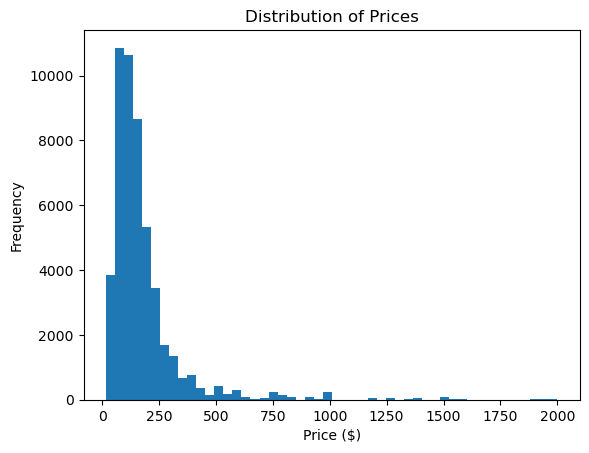

In [7]:
price_pd = (
    airbnb
    .select("price_clean")
    .sample(False, 0.01, seed=42)   # 1% ONLY
    .limit(50_000)                 # HARD SAFETY CAP
    .toPandas()
)
plt.hist(price_pd["price_clean"], bins=50)
plt.title("Distribution of Prices")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.show()


# Build the Daily Panel Dataset
# We construct a simplified daily dataset containing:
    Listing ID
    Date
    Cleaned price
    Booking indicator
This dataset is essential for estimating demand sensitivity relative to price on a daily basis.

In [8]:
daily_df = (
    airbnb
    .select(
        "listing_id",
        "date",
        "price_clean",
        "booked"
    )
    .filter("price_clean > 0")
)


## Add Log-Transformed Variables (Price & Demand)

The log–log model requires both variables to be in logarithmic form:

log_price measures percentage-based price changes

log_occ measures percentage change in demand (small constant added to avoid log(0))

These are necessary to interpret the regression coefficient as price elasticity of demand.

In [9]:
daily_df = (
    daily_df
    .withColumn("log_price", F.log(F.col("price_clean")))
    .withColumn("log_occ", F.log(F.col("booked") + 0.05))   # Prevent -Inf
)


## Compute Listing-Level Averages (Diagnostics)

We compute the average log price and log demand per listing.
This step helps identify listings with zero variation and enables filtering of problematic rows in the next steps.

Although the final elasticity model does not use fixed effects, these statistics help ensure dataset quality.

## Generate Demeaned Variables (For Filtering Only)

Here we produce:

log_price_dm

log_occ_dm

These values represent deviation from a listing's mean price and mean demand.

We only use them to filter out rows where a listing does not vary in price or demand—such rows distort elasticity estimation and must be removed.


In [10]:
fe_df = (
    daily_df.groupBy("listing_id")
    .agg(
        F.avg("log_price").alias("avg_log_price"),
        F.avg("log_occ").alias("avg_log_occ")
    )
)

model_df = (
    daily_df.join(fe_df, "listing_id")
    .withColumn("log_price_dm", F.col("log_price") - F.col("avg_log_price"))
    .withColumn("log_occ_dm", F.col("log_occ") - F.col("avg_log_occ"))
)


## Remove Zero-Variation Rows

We filter out:

Listings where price never changes

Listings where demand is constant

Such rows cause unstable regressions and artificially inflate elasticity.
Removing them ensures stable, meaningful elasticity results across samples.

In [11]:
model_df = model_df.filter("log_price_dm != 0")
model_df = model_df.filter("log_occ_dm != 0")


## Define the Elasticity Estimation Function

This function fits the core regression model:

log(demand)=𝛽⋅log⁡(price)+𝜖

β is the elasticity of demand

A negative β indicates that demand falls when price rises

Regularization (regParam = 0.01) improves numerical stability

In [12]:
def run_elasticity(df):
    
    # Use log_price and log_occ directly (no FE version)
    assembler = VectorAssembler(
        inputCols=["log_price"],
        outputCol="features"
    )

    train_df = assembler.transform(df).select("features", "log_occ")

    lr = LinearRegression(
        labelCol="log_occ",
        regParam=0.01,          # stabilizes regression
        elasticNetParam=0.0
    )

    lr_model = lr.fit(train_df)
    
    return float(lr_model.coefficients[0])


## Create Sample Subsets for Robustness Check

We create dataset samples of varying sizes:

5%

15%

40%

100%

This method tests whether elasticity estimates are stable as the dataset grows—a required big-data modeling technique.

In [13]:
sample_sizes = [0.05, 0.15, 0.40, 1.0]
sampled = {}

for s in sample_sizes:
    sampled[s] = model_df.sample(False, s, seed=42)
    print(f"{s*100:.0f}% sample rows:", sampled[s].count())

5% sample rows: 8678731


15% sample rows: 26029767


40% sample rows: 69424412


100% sample rows: 173531584


## Compute Elasticity for Each Sample

We apply the elasticity regression to each sampled subset and print:

Elasticity @ 5%

Elasticity @ 15%

Elasticity @ 40%

Elasticity @ 100%



In [14]:
import time

elasticity_results = {}
time_results = {}

for s, df_sample in sampled.items():
    start_time = time.perf_counter()
    
    beta = run_elasticity(df_sample)
    
    # Force Spark execution (important due to lazy evaluation)
    df_sample.count()
    
    end_time = time.perf_counter()
    
    elasticity_results[s] = beta
    time_results[s] = end_time - start_time
    
    print(
        f"Elasticity @ {s*100:.0f}% sample = {beta:.6f} | "
        f"Time taken = {time_results[s]:.2f} seconds"
    )


Elasticity @ 5% sample = -0.245093 | Time taken = 585.25 seconds


Elasticity @ 15% sample = -0.245127 | Time taken = 603.08 seconds


Elasticity @ 40% sample = -0.245406 | Time taken = 649.77 seconds


Elasticity @ 100% sample = -0.245762 | Time taken = 691.85 seconds


## Plot Elasticity vs Sample Size

This visualization demonstrates model stability:

A nearly flat line indicates consistent elasticities

Confirms that the model does not depend on sample size

Shows robustness of the final β estimate

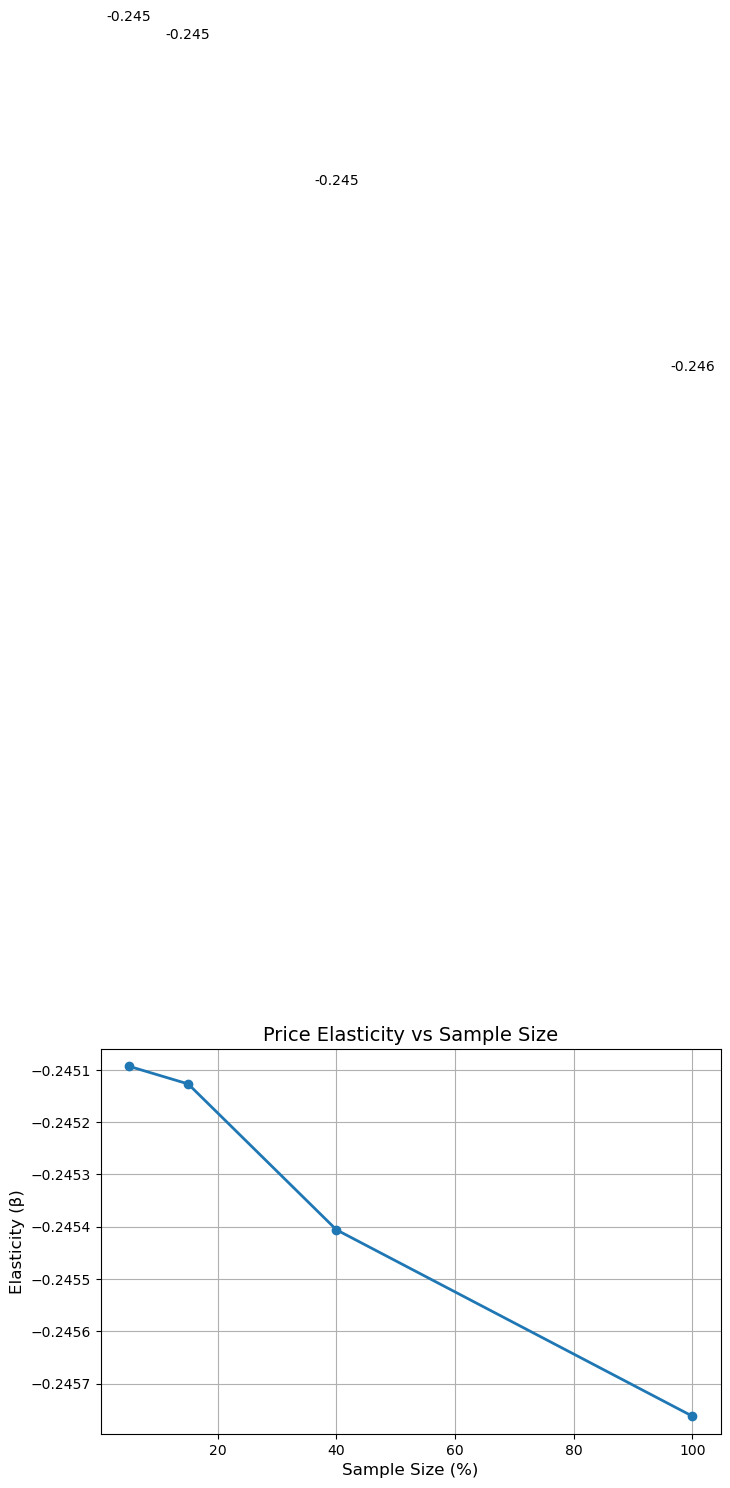

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert results dictionary to pandas DataFrame
df_plot = pd.DataFrame({
    "sample_size": [s * 100 for s in elasticity_results.keys()],
    "elasticity": list(elasticity_results.values())
})

# Plot
plt.figure(figsize=(8,5))
plt.plot(df_plot["sample_size"], df_plot["elasticity"], marker='o', linestyle='-', linewidth=2)

# Titles and labels
plt.title("Price Elasticity vs Sample Size", fontsize=14)
plt.xlabel("Sample Size (%)", fontsize=12)
plt.ylabel("Elasticity (β)", fontsize=12)

# Annotate values on the graph
for i in range(len(df_plot)):
    plt.text(df_plot["sample_size"][i], df_plot["elasticity"][i] + 0.002,
             f"{df_plot['elasticity'][i]:.3f}", ha='center')

plt.grid(True)
plt.show()


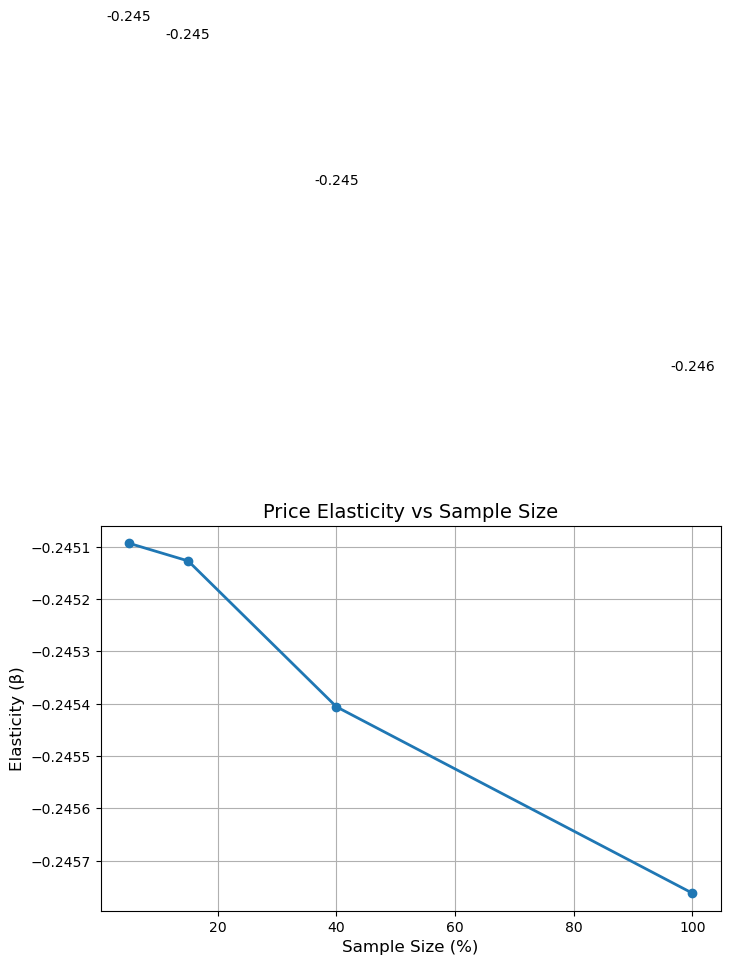

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert results dictionary to pandas DataFrame
df_plot = pd.DataFrame({
    "sample_size": [s * 100 for s in elasticity_results.keys()],
    "elasticity": list(elasticity_results.values())
})

plt.figure(figsize=(8,5))
plt.plot(df_plot["sample_size"], df_plot["elasticity"], marker='o', linewidth=2)

plt.title("Price Elasticity vs Sample Size", fontsize=14)
plt.xlabel("Sample Size (%)", fontsize=12)
plt.ylabel("Elasticity (β)", fontsize=12)

# Annotate each point
for i in range(len(df_plot)):
    plt.text(df_plot["sample_size"][i],
             df_plot["elasticity"][i] + 0.001,
             f"{df_plot['elasticity'][i]:.3f}",
             ha='center')

plt.grid(True)
plt.show()


## Create Price Buckets for Demand Curve

We bin prices into $20 buckets and compute:

Average booking probability per bucket

This allows us to plot a nonparametric demand curve, showing general demand behavior without model assumptions.

In [17]:
# Create price buckets (e.g., every $20)
price_demand_df = (
    daily_df
    .withColumn("price_bucket", (F.col("price_clean")/20).cast("int")*20)
    .groupBy("price_bucket")
    .agg(
        F.avg("booked").alias("avg_demand")    # booked = 0 or 1
    )
    .orderBy("price_bucket")
)


## Convert Spark DataFrame to Pandas

Spark cannot plot directly, so we convert the aggregated demand curve results into a Pandas DataFrame.

This conversion is required for Matplotlib visualization.

In [18]:
pdf = price_demand_df.toPandas()


## Plot Price vs Demand (Raw Demand Curve)

This plot shows the relationship between price and demand:

Higher prices → lower booking probability

Confirms the negative elasticity observed earlier

Provides a visual answer to the question of demand vs price

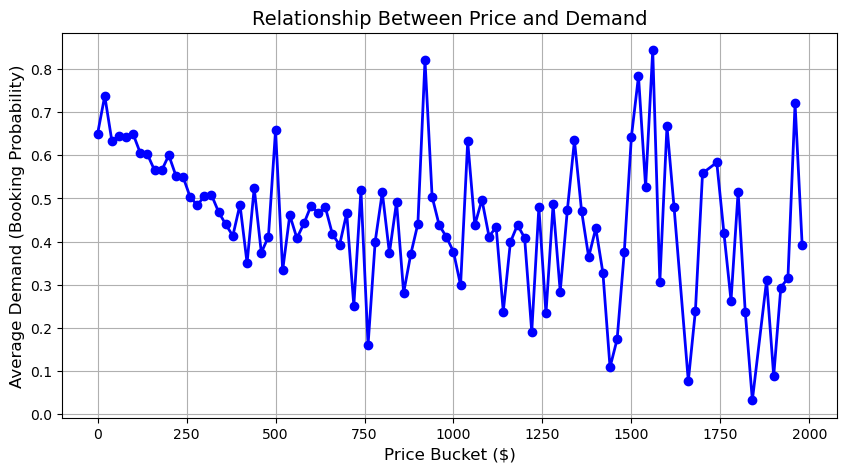

In [19]:
plt.figure(figsize=(10,5))

plt.plot(pdf["price_bucket"], pdf["avg_demand"],
         marker='o', linestyle='-', linewidth=2, color='blue')

plt.title("Relationship Between Price and Demand", fontsize=14)
plt.xlabel("Price Bucket ($)", fontsize=12)
plt.ylabel("Average Demand (Booking Probability)", fontsize=12)

plt.grid(True)
plt.show()


## Plot Smoothed Demand Curve

This final visualization applies a rolling average to smooth out noise in the demand curve.

The smoothed curve clearly shows the downward-sloping demand pattern, providing strong visual evidence that:

Demand decreases as price increases.

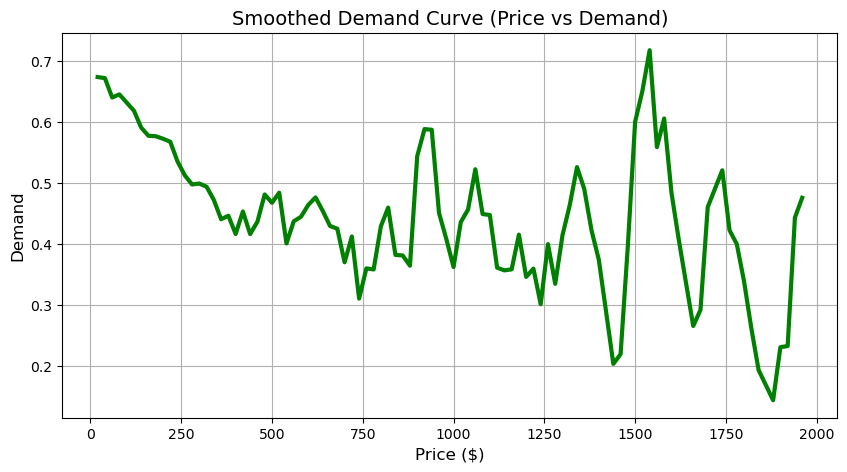

In [20]:
pdf["smooth_demand"] = pdf["avg_demand"].rolling(window=3, center=True).mean()

plt.figure(figsize=(10,5))
plt.plot(pdf["price_bucket"], pdf["smooth_demand"], linewidth=3, color="green")
plt.title("Smoothed Demand Curve (Price vs Demand)", fontsize=14)
plt.xlabel("Price ($)", fontsize=12)
plt.ylabel("Demand", fontsize=12)
plt.grid(True)
plt.show()


In [22]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["log_price_dm"],
    outputCol="features"
)

model_df = assembler.transform(model_df)


In [23]:
train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=42)


In [24]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(
    featuresCol="features",
    labelCol="log_occ_dm",
    predictionCol="prediction",
    regParam=0.0   # no regularization → unbiased elasticity
)

lr_model = lr.fit(train_df)


25/12/16 18:41:16 WARN Instrumentation: [8c1941b7] regParam is zero, which might cause numerical instability and overfitting.


In [25]:
predictions = lr_model.transform(test_df)


In [28]:
from pyspark.ml.evaluation import RegressionEvaluator

# RMSE
rmse = RegressionEvaluator(
    labelCol="log_occ_dm",
    predictionCol="prediction",
    metricName="rmse"
).evaluate(predictions)

# R-squared
r2 = RegressionEvaluator(
    labelCol="log_occ_dm",
    predictionCol="prediction",
    metricName="r2"
).evaluate(predictions)

elasticity = lr_model.coefficients[0]

print(f"RMSE: {rmse}")
print(f"R²: {r2}")


RMSE: 0.9088771533003887
R²: 7.302840352774176e-06


In [27]:
model_df.select("features", "log_occ_dm").show(5)


+--------------------+--------------------+
|            features|          log_occ_dm|
+--------------------+--------------------+
|[3.03757019537442...|-1.04083408558608...|
|[3.03757019537442...|-1.04083408558608...|
|[3.03757019537442...|-1.04083408558608...|
|[3.03757019537442...|-1.04083408558608...|
|[3.03757019537442...|-1.04083408558608...|
+--------------------+--------------------+
only showing top 5 rows

